# 04 - SHAP Explainability

This notebook explains the trained tree model at both global and local levels using SHAP.

The objective is to show which features drive high-risk predictions and to provide a customer-level explanation for compliance or model-risk review.

In [1]:
from pathlib import Path
import sys

def find_ml_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / '4_ml' / 'src').exists():
            return candidate / '4_ml'
        if candidate.name == '4_ml' and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the 4_ml workspace.')

ML_ROOT = find_ml_root()
if str(ML_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ML_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import shap

from config import MODEL_DIR, OUTPUT_DIR
from data_access import load_feature_frame
from features import build_model_frame, engineer_features, select_feature_columns
from explainability import compute_shap_values, normalize_shap_values, shap_importance_frame

import json
import os
import joblib

raw = load_feature_frame()
max_rows = int(os.getenv('ATB_NOTEBOOK_MAX_ROWS', '8000'))
if len(raw) > max_rows:
    raw = raw.sample(max_rows, random_state=42).sort_values('scoring_date').reset_index(drop=True)
frame = engineer_features(build_model_frame(raw))
feature_columns, numeric_columns, categorical_columns = select_feature_columns(frame)
feature_columns = list(dict.fromkeys(feature_columns))
X = frame[feature_columns].copy()
y = frame['risk_target'].astype(int)

summary_path = OUTPUT_DIR / 'training_summary.json'
best_name = json.loads(summary_path.read_text(encoding='utf-8'))['best_model'] if summary_path.exists() else 'xgboost'
for path in [MODEL_DIR / f'{best_name}_best_model.joblib', MODEL_DIR / f'{best_name}_best.pkl']:
    if path.exists():
        candidate_model = joblib.load(path)
        selected_model_name = best_name
        break
else:
    candidate_model = None
    selected_model_name = None

candidate_model is not None

True

In [2]:
shap_values, transformed_matrix, feature_names = compute_shap_values(candidate_model, X, sample_size=1000)
importance_frame = shap_importance_frame(shap_values, feature_names)
importance_frame.head(20)

,feature,mean_abs_shap
9,balance_per_account,3.403270
16,is_kyc_complete,3.003484
332,legal_capacity_flag_NON,0.419691
11,salary_to_balance_ratio,0.230660
311,segment_code_7.0,0.101444
333,legal_capacity_flag_OUI,0.022133
23,segment_code,0.018390
309,segment_code_5.0,0.000000
310,segment_code_6.0,0.000000
312,segment_code_8.0,0.000000


WindowsPath('C:/Users/Ahmed/Desktop/atb_bi_project/4_ml/outputs/shap_summary.png')

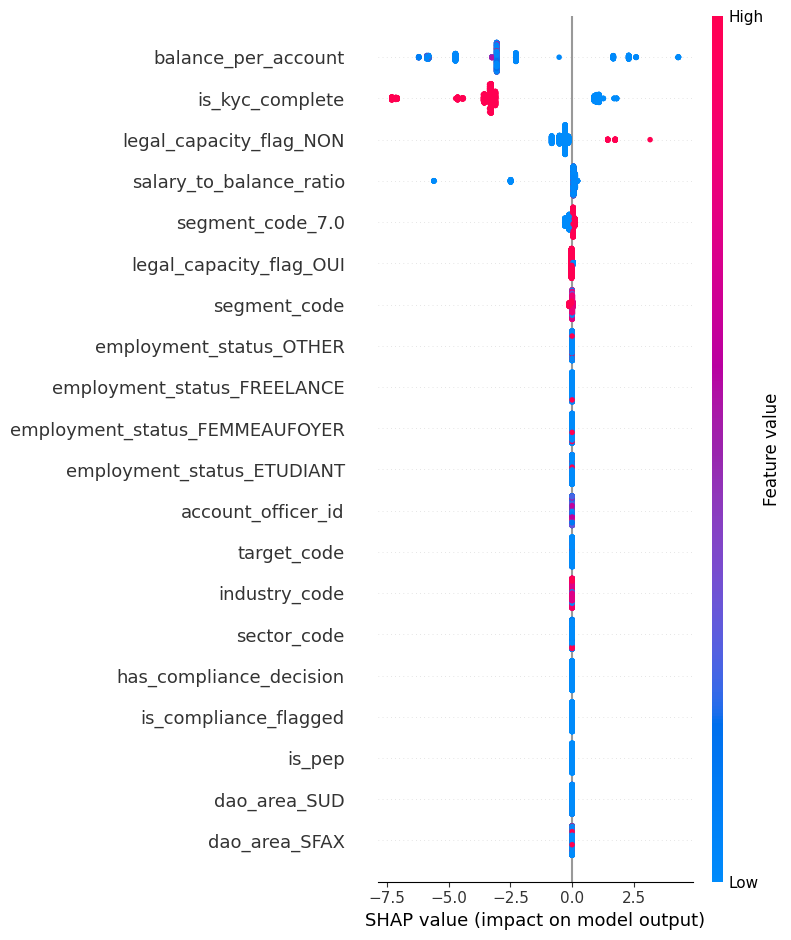

In [3]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, transformed_matrix, feature_names=feature_names, show=False)
global_plot_path = OUTPUT_DIR / 'shap_summary.png'
plt.tight_layout()
plt.savefig(global_plot_path, dpi=160, bbox_inches='tight')
global_plot_path

In [4]:
top_risk_index = int(candidate_model.predict_proba(X)[:, 1].argmax())
sample_row = X.iloc[[top_risk_index]]
from explainability import align_features, build_tree_explainer, get_feature_matrix
sample_row = align_features(candidate_model, sample_row)
explainer = build_tree_explainer(candidate_model)
sample_transformed, feature_names = get_feature_matrix(candidate_model, sample_row)
local_shap = normalize_shap_values(explainer.shap_values(sample_transformed))
base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, tuple)) else explainer.expected_value
shap.plots.waterfall(shap.Explanation(values=local_shap[0], base_values=base_value, data=sample_transformed[0], feature_names=feature_names), show=False)
local_plot_path = OUTPUT_DIR / 'shap_local_waterfall.png'
plt.tight_layout()
plt.savefig(local_plot_path, dpi=160, bbox_inches='tight')
local_plot_path

WindowsPath('C:/Users/Ahmed/Desktop/atb_bi_project/4_ml/outputs/shap_local_waterfall.png')

## Explainability output

- The global SHAP summary shows the most influential customer and account drivers.
- The local waterfall plot explains a single high-risk prediction in the same feature space used by the trained model.
- This notebook should be rerun whenever the final model or feature set changes so the explanations stay aligned with the deployed artifact.